# Tutorial for the KiLCA interface in python

This python notebook is a tutorial for the KiLCA interface in python and demonstrates its use. 

## Preparation

We start by invoking the sys module to add the path of the KiLCA_interface module. In projects lying in different directories, the path that is appended has to be changed accordingly! Also, we import os, numpy and matplotlib pyplot.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
sys.path.append('../')

Next, we can import the KiLCA_interface module.

In [2]:
from KiLCA_interface import *
from KiLCA_postprocessor import *

We declare now the path of the KiLCA run as well as the path to the profiles. Usually, the profile path is runpath + 'profiles/'. (Note that **all** directory paths should end with a slash.) At the same time as declaring the paths, we also make it if they are not present.

In [3]:
runpath = './runpath/'
prof_path = runpath + 'profiles/'
if not os.path.isdir(prof_path):
    os.makedirs(prof_path)

Now, we specify some information about the run itself. Since we will be using the create parabolic profiles method we also specify the values of the profiles they should have at the rational surface.

In [4]:
run_type = 'flre'   # other option would be 'vacuum'
machine  = 'AUG'    # other option would be MAST-U

m_mode = 6  # poloidal mode number
n_mode = 2  # toroidal mode number

q0 = 4.0        # safety factor parameter. 
n0 = 3e13       # density value at the rational surface [cm^-3]
Te0 = 1e3       # electron temperature value at the rational surface [eV]
Ti0 = 1e3       # ion temperature value at the rational surface [eV]
Vz0 = 1e7       # toroidal rotation velocity at the rational surface [cm/s]
Er0 = 0.5       # equilibrium radial electric field at the rational surface [statV/cm]
Vth0 = 1e6      # poloidal rotation velocity at the rational surface [cm/2]
rmin = 3.0      # minimum radius of the profiles, should in KiLCA be a few cm above 0
rmax = 67       # maximum radius of the profiles
num  = int(100) # number of radial grid points
a  = 67.2       # plasma radius. Must be smaller than rmax, otherwise profiles get negative.

shot = 0 # shot number. 0 because we use parabolic profiles
time = 0 # time slice. 0 because we use parabolic profiles

## Instantiating the class and running

Here, we create the KiLCA interface object, generate the profiles and run KiLCA. Also, we set the machine in the constructor of the interface to AUG. In this case, the machine parameters will be set immediately.

In [5]:
kil_in = KiLCA_interface(shot, time, runpath, run_type, machine)
# create the profiles:
kil_in.create_parabolic_profiles_from_res_surf(prof_path, q0, n0, Te0, Ti0, 
                                               Vz0, Er0, Vth0, m_mode, n_mode, 
                                               rmin, rmax, num, a)
# if machine type was not set in the constructor:
# kil_in.set_ASDEX(1)
kil_in.set_modes(m_mode, n_mode)
# write configuration files:
kil_in.write()
# run KiLCA:
kil_in.run()

Machine setting: AUG
Single RMP mode
The KiLCA run took 1.8366031646728516s
Output:



## Postprocessing

For postprocessing, we invoke the postprocessing class. This class takes as input either a KiLCA_interface object or the same argument list as the KiLCA_interface as well as the mode numbers m and n. Note that if the second option is used, the runpath has to contain a flre/vacuum directory containing the output of the KiLCA run.

For rapid analyis of the output, one can use the build in methods to plot the $B$($E$) field components.

KiLCA interface was parsed
    shot      : 0
    time slice: 0
    run path  : ./runpath/flre/
    run type  : flre
    machine   : AUG
available modes:
    m = 4    n = 2
    m = 5    n = 2
    m = 6    n = 2
    m = 7    n = 2
    m = 8    n = 2
    m = 6    n = 2


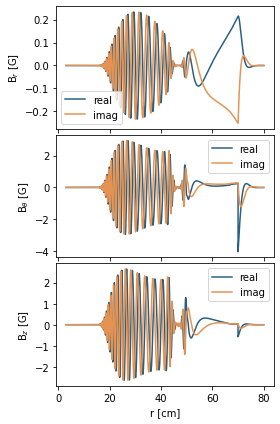

In [6]:
kil_post = KiLCA_postprocessor(kil_in)
_ = kil_post.plot_B_field(m=m_mode, n=n_mode)

Note that due to the parabolic profiles, the result shows oscillatory behavior.

To get the electromagnetic field data, we read the file with the postprocessing class.

In [7]:
EB_data = kil_post.read_EB(m=m_mode, n=n_mode)

Now the electromagnetic fields can be plotted individually.

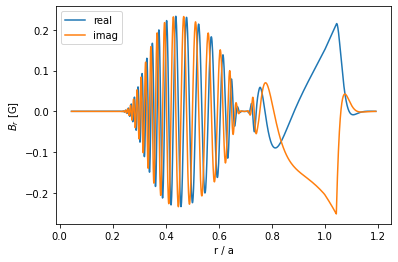

In [11]:
plt.figure()
plt.plot(EB_data['(6, 2)'][:,0]/a, EB_data['(6, 2)'][:,7], label='real')
plt.plot(EB_data['(6, 2)'][:,0]/a, EB_data['(6, 2)'][:,8], label='imag')
plt.legend()
plt.xlabel('r / a')
plt.ylabel(r'$B_r$ [G]')
plt.show()

It is also possible to read the data into the postprocessing object.

In [17]:
kil_post.EB_to_fields(EBdat=kil_post.read_EB(m=6,n=2), m=m_mode, n=n_mode)

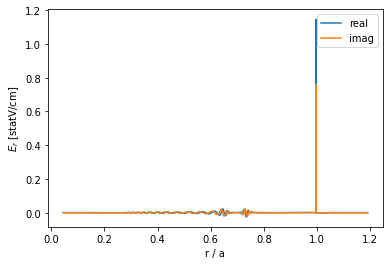

In [18]:
plt.figure()
plt.plot(kil_post.r/a, kil_post.Er_real, label='real')
plt.plot(kil_post.r/a, kil_post.Er_imag, label='imag')
plt.legend()
plt.xlabel('r / a')
plt.ylabel(r'$E_r$ [statV/cm]')
plt.show()